## Feature Engineering | Encoding | Correlation

##### 1.Feature Engineering

In [2]:
import pandas as pd
import numpy as np

bois = pd.read_csv('./bios.CSV')
bois.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [6]:
# Create new column by combining height and weight into a BMI-like ratio
bois['height_weight_ratio'] = bois['height_cm'] / bois['weight_kg']
bois[['name','height_cm','height_weight_ratio']].head()

,name,height_cm,height_weight_ratio
0,Jean-François Blanchy,NaN,NaN
1,Arnaud Boetsch,183.0,2.407895
2,Jean Borotra,183.0,2.407895
3,Jacques Brugnon,168.0,2.625000
4,Albert Canet,NaN,NaN


In [11]:
# Extract birth year from born_date as a new feature
bois['born_date'] = pd.to_datetime(bois['born_date']) # column from text (string) to date format
bois['birth_year'] = bois['born_date'].dt.year
bois[['name','born_date','birth_year']].head()
                                   

,name,born_date,birth_year
0,Jean-François Blanchy,1886-12-12,1886.0
1,Arnaud Boetsch,1969-04-01,1969.0
2,Jean Borotra,1898-08-13,1898.0
3,Jacques Brugnon,1895-05-11,1895.0
4,Albert Canet,1878-04-17,1878.0


In [13]:
# Use apply() with lambda on text, extract first name from full name 
bois['first_name'] = bois['name'].apply(lambda x: x.split()[0] if isinstance(x, str) else x)
bois[['name','first_name']].head()

,name,first_name
0,Jean-François Blanchy,Jean-François
1,Arnaud Boetsch,Arnaud
2,Jean Borotra,Jean
3,Jacques Brugnon,Jacques
4,Albert Canet,Albert


In [20]:
# Use apply() with lambda to create a column flagging tall athletes (height > 190)
bois['is_tall'] = bois['height_cm'].apply(lambda x: 1 if x > 100 else 0)
bois[['name','height_cm','is_tall']].head(10)

,name,height_cm,is_tall
0,Jean-François Blanchy,NaN,0
1,Arnaud Boetsch,183.0,1
2,Jean Borotra,183.0,1
3,Jacques Brugnon,168.0,1
4,Albert Canet,NaN,0
5,Nicolas Chatelain,181.0,1
6,Patrick Chila,180.0,1
7,Henri Cochet,NaN,0
8,Marcel Cousin,NaN,0
9,Guy de la Chapelle,NaN,0


In [26]:
#  divides people into height groups (Short, Medium, Tall, Very Tall) based on their height and then shows the first 10 rows.
bois['height_category'] = pd.cut(     #divides numbers into ranges
    bois['height_cm'],
    bins=[0,165,180,195,300],
    labels=['Short','Medium','Tall','Very Tall']
)
bois[['name','height_cm','height_category']].head(10)

,name,height_cm,height_category
0,Jean-François Blanchy,NaN,NaN
1,Arnaud Boetsch,183.0,Tall
2,Jean Borotra,183.0,Tall
3,Jacques Brugnon,168.0,Medium
4,Albert Canet,NaN,NaN
5,Nicolas Chatelain,181.0,Tall
6,Patrick Chila,180.0,Medium
7,Henri Cochet,NaN,NaN
8,Marcel Cousin,NaN,NaN
9,Guy de la Chapelle,NaN,NaN


In [29]:
# changes some column names to shorter and cleaner names, saves the updated table in a new variable, and shows the first few rows.
bois_clean = bois.rename(columns={
    'height_cm': 'height',
    'weight_kg': 'weight',
    'born_country': 'country'
})
bois_clean.head()

,athlete_id,name,born_date,born_city,born_region,country,NOC,height,weight,died_date,height_weight_ratio,birth_year,first_name,is_tall,height_category
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,NaN,1886.0,Jean-François,0,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,2.407895,1969.0,Arnaud,1,Tall
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,2.407895,1898.0,Jean,1,Tall
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,2.625000,1895.0,Jacques,1,Medium
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,NaN,1878.0,Albert,0,NaN


In [31]:
# Drop columns that are not useful as features for ML
bois_clean = bois.drop(columns=['born_date','first_name'])
bois_clean.head()

,athlete_id,name,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year,is_tall,height_category
0,1,Jean-François Blanchy,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,NaN,1886.0,0,NaN
1,2,Arnaud Boetsch,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,2.407895,1969.0,1,Tall
2,3,Jean Borotra,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,2.407895,1898.0,1,Tall
3,4,Jacques Brugnon,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,2.625000,1895.0,1,Medium
4,5,Albert Canet,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,NaN,1878.0,0,NaN


##### Encoding Categorical data

In [33]:
# finds and shows the names of all columns that contain text (categorical data) in the dataframe.
bois.select_dtypes(include='object').columns

Index(['name', 'born_city', 'born_region', 'born_country', 'NOC', 'died_date',
       'first_name'],
      dtype='object')

In [37]:
# converts the country names (text) into numbers (0 and 1) by creating separate columns for each country, then shows the first few rows.
encoded = pd.get_dummies(bois[['born_country']], columns=['born_country'])
encoded.head()

,born_country_AFG,born_country_AGU,born_country_ALB,born_country_ALG,born_country_AND,born_country_ANG,born_country_ANT,born_country_ARG,born_country_ARM,born_country_ARU,...,born_country_UZB,born_country_Upland,born_country_VAN,born_country_VEN,born_country_VIE,born_country_VIN,born_country_Vienna,born_country_YEM,born_country_ZAM,born_country_ZIM
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [44]:
!pip install scikit-learn
import sklearn
from sklearn.preprocessing import LabelEncoder

# converts country names (text) into numbers so that Machine Learning models can understand them.
le = LabelEncoder()
bois['country_encoded'] = le.fit_transform(bois['born_country'].fillna('Unknown'))
bois[['name','born_country','country_encoded']].head(10)

,name,born_country,country_encoded
0,Jean-François Blanchy,FRA,74
1,Arnaud Boetsch,FRA,74
2,Jean Borotra,FRA,74
3,Jacques Brugnon,FRA,74
4,Albert Canet,GBR,78
5,Nicolas Chatelain,FRA,74
6,Patrick Chila,FRA,74
7,Henri Cochet,FRA,74
8,Marcel Cousin,FRA,74
9,Guy de la Chapelle,FRA,74


In [46]:
# converts height categories (text like Short, Medium, Tall) into numbers (0,1,2,3) and then shows the first 10 rows.
order_map = {'Short':0, 'Medium':1, 'Tall':2, 'Very Tall':3}
bois['height_encoded'] = bois['height_category'].map(order_map)
bois[['name','height_category','height_encoded']].head(10)

,name,height_category,height_encoded
0,Jean-François Blanchy,NaN,NaN
1,Arnaud Boetsch,Tall,2
2,Jean Borotra,Tall,2
3,Jacques Brugnon,Medium,1
4,Albert Canet,NaN,NaN
5,Nicolas Chatelain,Tall,2
6,Patrick Chila,Medium,1
7,Henri Cochet,NaN,NaN
8,Marcel Cousin,NaN,NaN
9,Guy de la Chapelle,NaN,NaN


In [48]:
print(bois['born_country'].nunique())      # number of unique country
print(bois['born_city'].nunique())         # number of unique cities

236
22368


##### Correlation Analysis

In [50]:
# # Select only numeric columns for correlation — corr() only works on numbers
numeric_bois = bois[['height_cm','weight_kg','birth_year','is_tall','height_weight_ratio']]
numeric_bois.head()

,height_cm,weight_kg,birth_year,is_tall,height_weight_ratio
0,NaN,NaN,1886.0,0,NaN
1,183.0,76.0,1969.0,1,2.407895
2,183.0,76.0,1898.0,1,2.407895
3,168.0,64.0,1895.0,1,2.625000
4,NaN,NaN,1878.0,0,NaN


In [52]:
# Compute correlation matrix — values range from -1 to 1
# 1 means perfect positive relationship, -1 means perfect negative, 0 means no relationship
numeric_bois.corr()

,height_cm,weight_kg,birth_year,is_tall,height_weight_ratio
height_cm,1.000000,0.779290,0.006908,NaN,-0.651453
weight_kg,0.779290,1.000000,-0.037957,NaN,-0.947003
birth_year,0.006908,-0.037957,1.000000,0.410861,0.077377
is_tall,NaN,NaN,0.410861,1.000000,NaN
height_weight_ratio,-0.651453,-0.947003,0.077377,NaN,1.000000


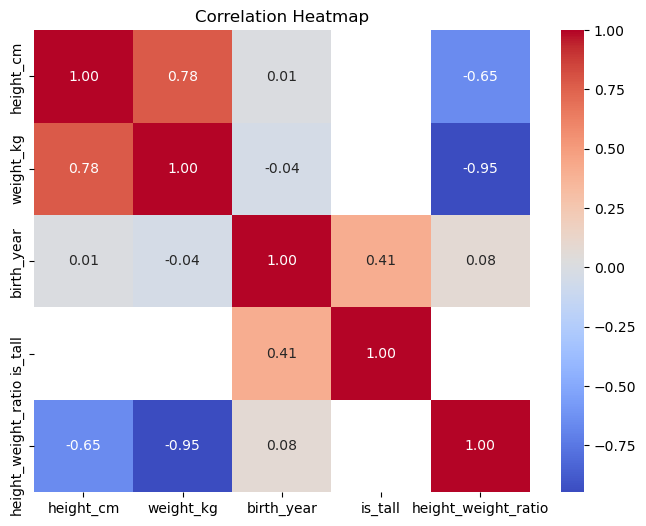

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize correlation as a heatmap — easier to read than raw numbers
plt.figure(figsize=(8, 6))
sns.heatmap(
    numeric_bois.corr(),
    annot=True,     # show numbers inside boxes
    cmap='coolwarm',     # red = high correlation, blue = low
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

In [55]:
# Find features most correlated with height — helps decide which features matter
numeric_bois.corr()['height_cm'].sort_values(ascending=False)

height_cm              1.000000
weight_kg              0.779290
birth_year             0.006908
height_weight_ratio   -0.651453
is_tall                     NaN
Name: height_cm, dtype: float64

In [56]:
import numpy as np
import pandas as pd
corr-matrix = numeric_bois.corr().abs()
upper = corr_matrix.where(pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print('Columns to drop to high correlation: ', to_drop)

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (513878896.py, line 3)